# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who**<br>
Public health officials healthcare advocators who are looking to spread awareness for diabetes prevention.

**What**<br>
Adults with low physical activity, and high blood pressure have higher rates of diabetes and efforts should be made on having a better lifestyle.

**How**<br>
Using clear visuals to show how diabetes increases across risk factors like BMI, physical activity, general health

# 3. Homework - work with your own data

In [109]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe() ✅

- Are there any duplicate rows? ✅

- Are there any duplicate values in a given column (when this would be inappropriate?) ✅

- What are the mean, median, and mode of each column? ✅

- Are there any missing or null values? ✅

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.) ✅

- Encode any categorical variables (e.g. with one-hot encoding.) ✅

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

### *Reading in the Dataset:*

In [110]:
# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", path)

# I googled: How to read a Kaggle dataset into Python?

# lists all the files in the downloaded folder
files = os.listdir(path)
print("Files:", files)
# the file I want
df_file = files[0]
# Join the folder path with the dataset file and read
df = pd.read_csv(os.path.join(path, df_file))

df.head()

Path to dataset files: C:\Users\minhh\.cache\kagglehub\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1
Files: ['diabetes_012_health_indicators_BRFSS2015.csv', 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv']


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### *Info() and Describe()*

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [112]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### *Mean, Median, Mode for each column*

In [113]:
df_means = df.mean(numeric_only=True)
df_medians = df.median(numeric_only=True)
df_modes = df.mode().iloc[0]

df_mmm_summary = pd.DataFrame([df_means, df_medians, df_modes], index=["mean", "median", "mode"])

df_mmm_summary


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
mean,0.296921,0.429001,0.424121,0.96267,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
median,0.000000,0.000000,0.000000,1.00000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
mode,0.000000,0.000000,0.000000,1.00000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,9.000000,6.000000,8.000000


### *Null Values Check*

In [114]:
# How many null values are in each column?
print(df.isna().sum())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


### *Duplicate Checks*

In [115]:
num_dups = df.duplicated().sum()

print(f"There are a total of {num_dups} duplicate rows")

There are a total of 23899 duplicate rows


Although there are 23,899 duplicate rows, I will not remove them because the dataset consists of survey responses, and it is possible for multiple participants to provide identical answers.

Regarding duplicate values within individual columns, there are no ID fields or unique identifiers in the dataset. Therefore, checking for duplicates at the column level is not meaningful in this context since each column is either binary or representing numerical categories.

### *Encoding any Categorical Variables*

In [116]:
categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()
print(categorical_features)

#Based on the output, it looks like all the features have been encoded

[]


### *Any Inconsistency with Age*

In [117]:
# I googled: How to identify elements with less or greather than conditions in DataFrame?
invalid_age = df[(df["Age"] < 0) | (df["Age"] > 13)]
print(invalid_age)
# Based on the results, all values are between 1 and 13, which matches the ordinal category

Empty DataFrame
Columns: [Diabetes_012, HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income]
Index: []

[0 rows x 22 columns]


### *Graphs*

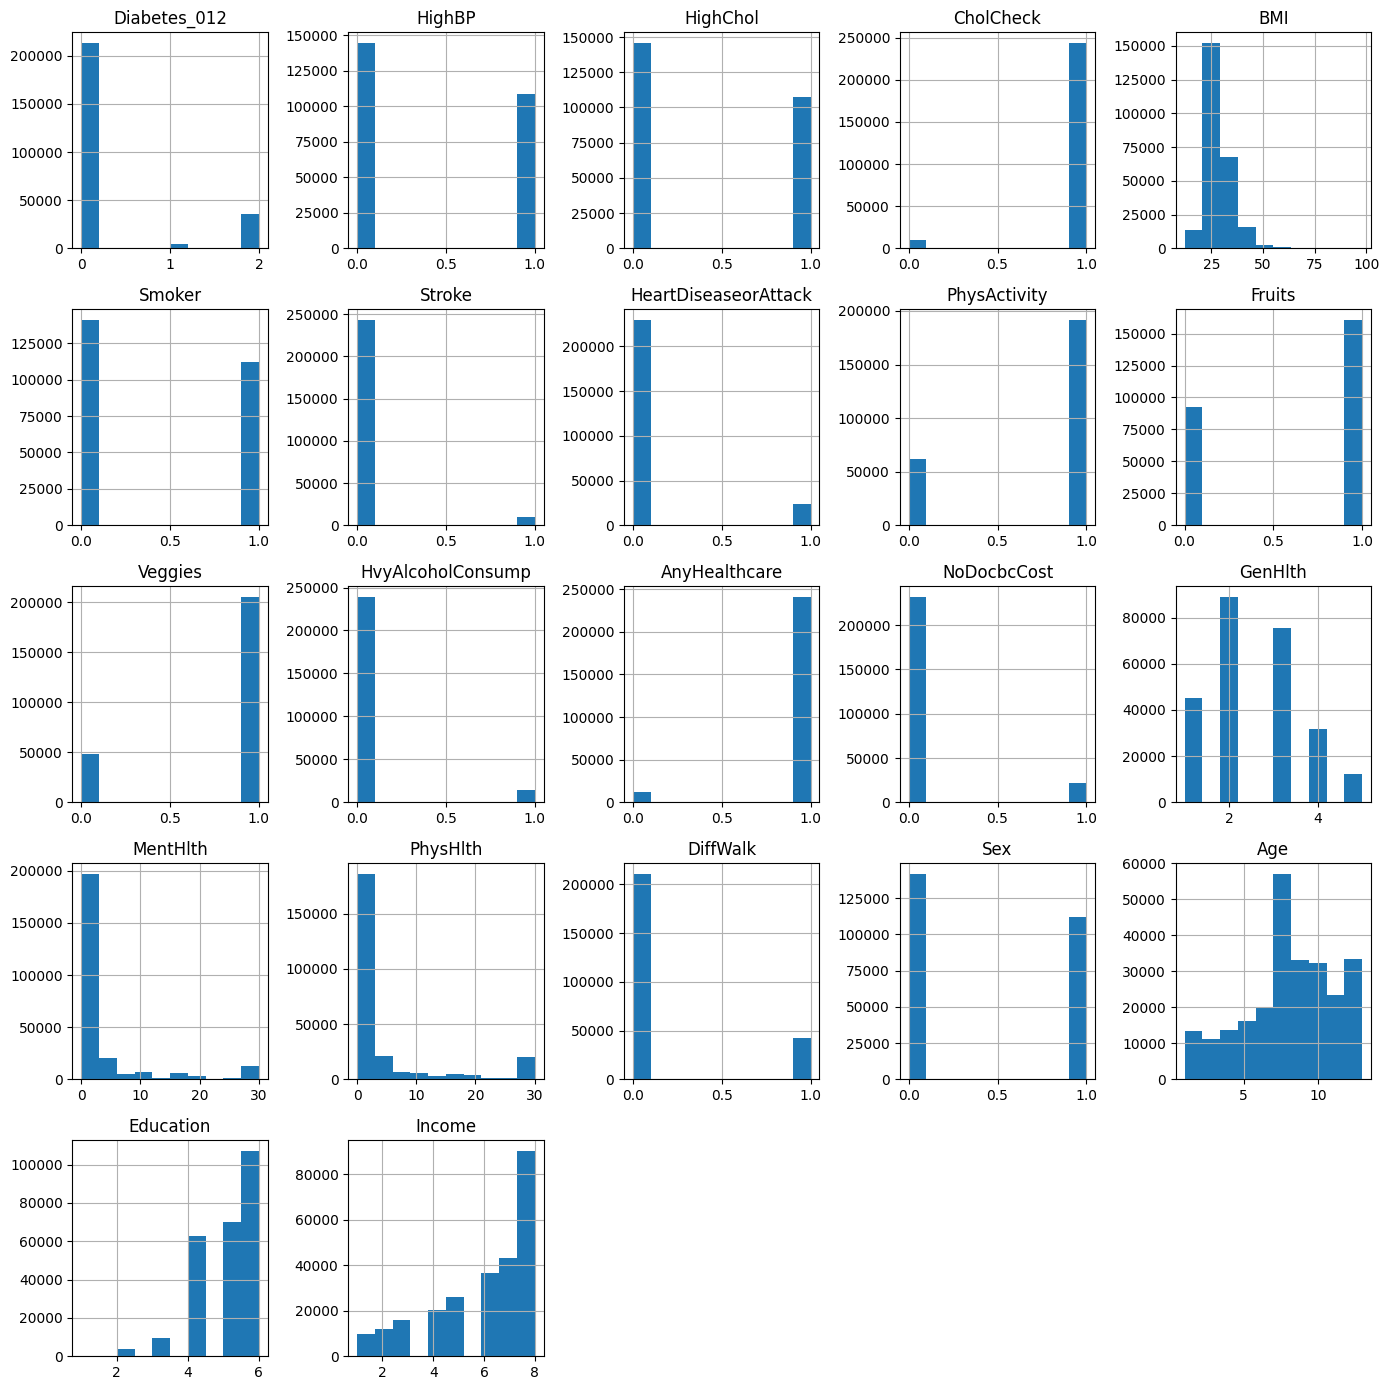

In [118]:
df.hist(figsize=(14, 14), bins=10);
plt.tight_layout()

# Most of the features are either binary or ordinal

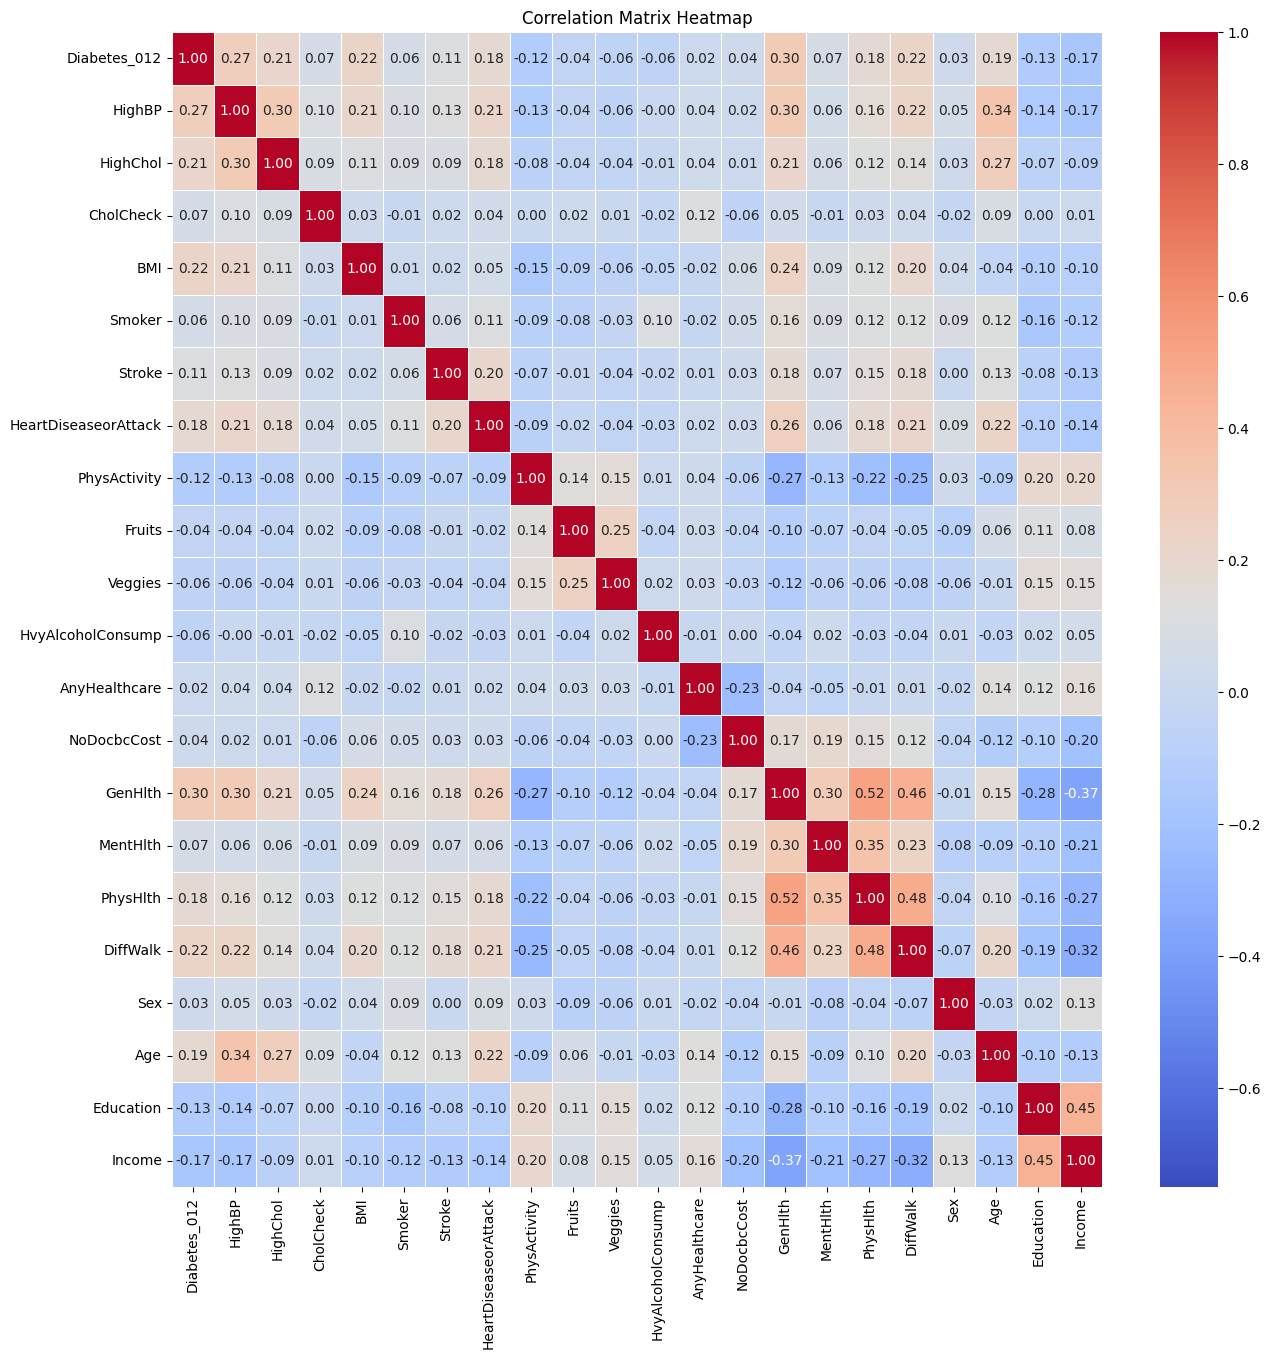

In [119]:
corr = df.corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr, 
            annot=True,        
            cmap="coolwarm",   
            fmt=".2f",
            vmin=-.75,
            linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

### Conclusions:

- Are the data usable?  If not, find some new data!
*Yes because this dataset is properly encoded and doesn't contain any null values*

- Do you need to modify or correct the data in some way?
*I didn't need to make any adjustment to the dataset*

- Is there any class imbalance?  (Categories that have many more items than other categories).
*Yes, if we look at the histograms above, we see that some of the variables have more responses in one category compared to others (Diabetes_012, Income with majority leaning towards higher income)*

# Appendix

| Variable             | Description                                                                                                                                                                                                                                                                                                                                               |
|----------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Diabetes_012             | 0 = no diabetes<br>1 = prediabetes<br>2 = diabetes                                                                                                                                                                                                                                                                                                        |
| HighBP               | 0 = no high BP<br>1 = high BP                                                                                                                                                                                                                                                                                                                             |
| HighChol             | 0 = no high cholesterol<br>1 = high cholesterol                                                                                                                                                                                                                                                                                                           |
| CholCheck            | 0 = no cholesterol check in 5 years<br>1 = yes cholesterol check in 5 years                                                                                                                                                                                                                                                                               |
| BMI                  | Body Mass Index                                                                                                                                                                                                                                                                                                                                           |
| Smoker               | Have you smoked at least 100 cigarettes in your entire life?<br>[Note: 5 packs = 100 cigarettes]<br>0 = no <br>1 = yes                                                                                                                                                                                                                                    |
| Stroke               | (Ever told) you had a stroke. <br>0 = no <br>1 = yes                                                                                                                                                                                                                                                                                                      |
| HeartDiseaseorAttack | Coronary heart disease (CHD) or myocardial infarction (MI)<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                           |
| PhysActivity         | Physical activity in past 30 days - not including job<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                                |
| Fruits               | Consume Fruit 1 or more times per day<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                                                |
| Veggies              | Consume Vegetables 1 or more times per day<br>0 = no<br>1 = yes                                                                                                                                                                                                                                                                                           |
| HvyAlcoholConsump    | Heavy drinkers (adult men having more than 14 drinks per week<br>and adult women having more than 7 drinks per week)<br>0 = no<br>1 = yes                                                                                                                                                                                                                 |
| AnyHealthCare        | Have any kind of health care coverage, including health insurance<br>insurance, prepaid plans such as HMO, etc.<br>0 = no<br>1 = yes                                                                                                                                                                                                                      |
| NoDocbcCost          | Was there a time in the past 12 months when you needed to see <br>a doctor, but could not because of cost?<br>0 = no<br>1 = yes                                                                                                                                                                                                                           |
| GenHlth              | Would you say that in general your health is: scale 1-5<br>1 = excellent<br>2 = very good<br>3 = good<br>4 = fair<br>5 = poor                                                                                                                                                                                                                             |
| MentHlth             | Now thinking about your mental health, which includes<br>stress, depression, and problems with emotions, for <br>how many days during the past 30 days was your mental <br>health not good? scale 1-30 days                                                                                                                                               |
| PhysHlth             | Now thinking about your physical health, which includes<br>physical illness and injury, for how many days during<br>the past 30 days was your physical health not good? <br>scale 1-30 days                                                                                                                                                               |
| DiffWalk             | Do you have serious difficulty walking or climbing stairs? <br>0 = no <br>1 = yes                                                                                                                                                                                                                                                                         |
| Sex                  | 0 = female<br>1 = male                                                                                                                                                                                                                                                                                                                                    |
| Age                  | 13-level age category (_AGEG5YR see codebook)<br>1 = 18-24<br>9 = 60-64<br>13 = 80 or older                                                                                                                                                                                                                                                               |
| Education            | Education level (EDUCA see codebook) scale 1-6<br>1 = Never attended school or only kindergarten<br>2 = Grades 1 through 8 (Elementary)<br>3 = Grades 9 through 11 (Some high school)<br>4 = Grade 12 or GED (High school graduate)<br>5 = College 1 year to 3 years (Some college or technical school)<br>6 = College 4 years or more (College graduate) |
| Income               | Income scale (INCOME2 see codebook) scale 1-8<br>1 = less than $10,000<br>5 = less than $35,000<br>8 = $75,000 or more                                                                                                                                                                                                                                    |

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

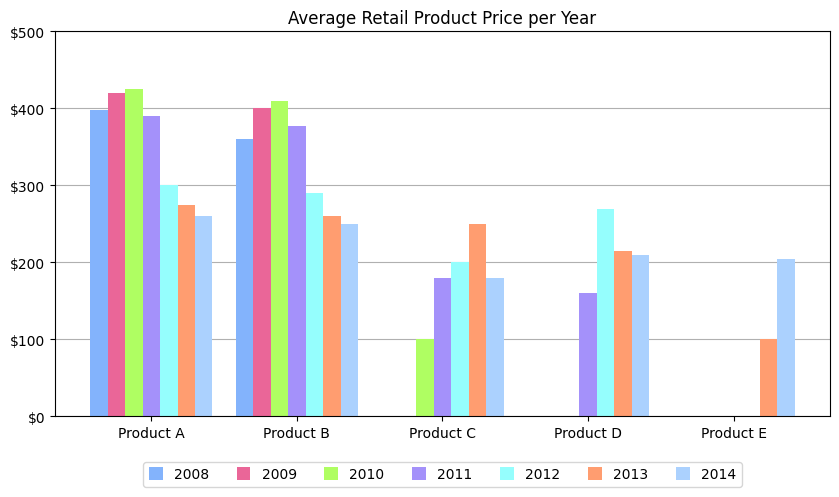

In [ ]:
import matplotlib.ticker as mtick

# I googled how to create a grouped bar graph? I got an example code for a simple multiple
# bar graph and adjusted the data and width to match the graph in the book

categories = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
year_2008 = [398, 360, 0, 0, 0]
year_2009 = [420, 400, 0, 0, 0]
year_2010 = [425, 410, 100, 0, 0]
year_2011 = [390, 377, 180, 160, 0]
year_2012 = [300, 290, 200, 270, 0]
year_2013 = [275, 260, 250, 215, 100]
year_2014 = [260, 250, 180, 210, 205]

colors = ["#83b3fc", "#ea6698", "#affe62", "#a491fa", "#95fefd", "#ff9d70", "#abd1fe"]


x = np.arange(len(categories))
bar_width = 0.12

years = [year_2008, year_2009, year_2010, year_2011,
         year_2012, year_2013, year_2014]

labels = ['2008','2009','2010','2011','2012','2013','2014']

plt.figure(figsize=(10,5))

for i in range(len(years)):
    plt.bar(x + i*bar_width, years[i], color=colors[i], width=bar_width, label=labels[i])

plt.title("Average Retail Product Price per Year")
plt.xticks(x + bar_width*3, categories)

# I asked ChatGPT how to give currency to the y axis
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))\

plt.ylim(top=500)
# I googled how to make the legend at the bottom of the graph in Matplotlib
plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=7,
           handlelength=1,
           handleheight=1)
# horizontal line behind the bars
ax.set_axisbelow(True)
plt.grid(True, axis="y")

plt.show()